In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import random
from multiprocessing import Pool
from functools import partial

import os, sys
from scipy import optimize
sys.path.append(os.path.abspath('../../Software/.'))
import rate_methods_library as RM

In [2]:
true = 1.4328652141523972e-6
k_low = 0.2219796815459443 # np.log(true) - 0.06748333798671914
k_high = 0.46802748239726666 # np.log(true) + 0.06748333798671914
log_name = 'p.log'
colvar_name = 'opes.colvar'
runs = [f"run_{i+1}" for i in range(100)]
plog_len = 1
beta = 1. / (312.*0.008314)
print(np.log(true*1e6))

0.35967608591032063


In [3]:
true = 1.4328652141523972e-6
k_low = 0.2219796815459443 # np.log(true) - 0.06748333798671914
k_high = 0.46802748239726666 # np.log(true) + 0.06748333798671914
log_name = 'p.log'
colvar_name = 'opes_short.colvar'
beta = 1. / (312.*0.008314)

runs = [f'run_{i+1}' for i in range(100)]

def get_data(directory,biascol=3):
    colvars = []
    for run in runs:
        colvars.append(f"{directory}/{run}/{colvar_name}")
    
    data = [] # data[i][j,k] is column k of simulation i at the time of row j.
    for colvar in colvars:
        data.append(np.loadtxt(colvar, usecols=[0,biascol]))

    return data

#gammas = np.linspace(0,1,20)
#Ns = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]
#Ns = [10,20,30,40,50,60,70,80,90,100]
barrs = ['5','7','9','11','13']

#def get_maxrow_count(data):
#    colvars_maxrow_count = 0
#    for colvar in data:
#        if colvars_maxrow_count < colvar.shape[0]:
#            colvars_maxrow_count = colvar.shape[0]
#    return colvars_maxrow_count

poisson_CDF = lambda t, k : 1. - np.exp(-k*t)

def get_sample(data, N, barrs_samp, axis, seed):
    total_time = 0
    accelerated_times = []
    v_datas = {}
    emp_rates = {}
    ecdfys = np.linspace(1/N,1,N)
    for barr in barrs_samp:

        random.seed(seed)
        run_idxs = [random.randint(0,99) for i in range(N)]
        rdata = [data[barr][idx] for idx in run_idxs]
    
        final_times = [rdatum[-1][0] for rdatum in rdata]
        total_time += np.sum(final_times)

        ecdfxs = np.sort(final_times)
        #emp_rate = N / np.sum(final_times)
        emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs,ecdfys,p0=1e-6)[0][0]
        emp_rates[barr] = emp_rate
    
        colvar_maxrow_count = max(len(traj[:,0]) for traj in rdata)
        v_data = np.full((len(rdata), colvar_maxrow_count), np.nan)
        for i, traj in enumerate(rdata):
            v_data[i,:len(traj)] = traj[:,1]+np.float64(barr)
        v_datas[barr] = v_data
        
        #v_data, ix_col = RM.inst_bias(rdata, N, colvars_maxrow_count, beta, 1, bias_shift=np.float64(barr))
        #v_datas[barr] = v_data
        #acc_factors = RM.calc_acc(rdata, 0, 1, beta, bias_shift=np.float64(barr))
        #accelerated_times=accelerated_times+list(np.array(final_times)*acc_factors)
        accelerated_times = accelerated_times+[traj[-1,0]*np.mean(np.exp(np.float64(beta*(traj[:,1] + np.float64(barr))))) for traj in rdata]

    def variance(gamma):
        k0s = []
        for barr in barrs_samp:
            avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas[barr]),axis=axis))
            k0s.append(np.log(emp_rates[barr])-np.log(avg))
        return np.var(k0s)

    gamma_best = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
    k0s = []
    for barr in barrs_samp:
        avg = np.mean(np.nanmean(np.exp(beta*gamma_best*v_datas[barr]),axis=axis))
        k0s.append(np.log(emp_rates[barr])-np.log(avg))
    k0_best = np.mean(k0s)
    
    ecdfys = np.linspace(1/(N*len(barrs_samp)),1,N*len(barrs_samp))
    imd_rate = optimize.curve_fit(poisson_CDF,np.sort(accelerated_times),ecdfys,p0=1e-8)[0][0]

    return [np.log(imd_rate),k0_best,gamma_best,total_time]

def get_Ndata(directory,letter,axis=0,biascol=3,a=5,Ns=[10,20,30,40,50,60,70,80,90,100],seed=None):
    print(directory)
    data = {}
    for barr in barrs:
        data[barr] = get_data(f'{directory}/{letter}runs_barr{barr}',biascol=biascol)
    
    imetad_out = []
    imetad_std = []
    gammas_out = []
    gammas_std = []
    logk0s_out = []
    logk0s_std = []
    totals_out = []
    totals_std = []

    if a > 0:
        barrs_samp = barrs[:a]
    else:
        barrs_samp = barrs[a:]
    
    for N in Ns:
    
        print(N)
        p = Pool(4)
        func = partial(get_sample, data, N, barrs_samp, axis)
        results = np.array(p.map(func, range(1000)))
        p.close()
        imetad_samples = results[:,0]
        logk0s_samples = results[:,1]
        gammas_samples = results[:,2]
        totals_samples = results[:,3]
            
        imetad_out.append(np.mean(imetad_samples))
        imetad_std.append(np.std(imetad_samples))
        logk0s_out.append(np.mean(logk0s_samples))
        logk0s_std.append(np.std(logk0s_samples))
        gammas_out.append(np.mean(gammas_samples))
        gammas_std.append(np.std(gammas_samples))
        totals_out.append(np.mean(np.log(totals_samples)))
        totals_std.append(np.std(np.log(totals_samples)))

    return np.vstack((Ns,totals_out,totals_std,logk0s_out,logk0s_std,gammas_out,gammas_std,imetad_out,imetad_std)).T

print('ran')

ran


In [4]:
def get_OPESf_low_sample(data, N, axis, seed):
    
    accelerated_times = []
    ecdfys = np.linspace(1/N,1,N)

    random.seed(seed)
    run_idxs = [random.randint(0,99) for i in range(N)]
    rdata = [data[idx] for idx in run_idxs]

    final_times = [rdatum[-1][0] for rdatum in rdata]
    total_time = np.sum(final_times)
    
    accelerated_times = accelerated_times+[traj[-1,0]*np.mean(np.exp(np.float64(beta*(traj[:,1] + np.float64(barrs[0]))))) for traj in rdata]

    imd_rate = optimize.curve_fit(poisson_CDF,np.sort(accelerated_times),ecdfys,p0=1e-8)[0][0]

    return [np.log(imd_rate),total_time]

def get_OPESf_low_Ndata(directory,letter,axis=0,biascol=3,Ns=[10,20,30,40,50,60,70,80,90,100],seed=None):
    print(directory)
    data = get_data(f'{directory}/{letter}runs_barr{barrs[0]}',biascol=biascol)
    
    imetad_out = []
    imetad_std = []
    gammas_out = []
    gammas_std = []
    logk0s_out = []
    logk0s_std = []
    totals_out = []
    totals_std = []
    
    for N in Ns:
    
        print(N)
        p = Pool(4)
        func = partial(get_OPESf_low_sample, data, N, axis)
        results = np.array(p.map(func, range(1000)))
        p.close()
        imetad_samples = results[:,0]
        totals_samples = results[:,1]
            
        imetad_out.append(np.mean(imetad_samples))
        imetad_std.append(np.std(imetad_samples))
        totals_out.append(np.mean(np.log(totals_samples)))
        totals_std.append(np.std(np.log(totals_samples)))

    return np.vstack((Ns,totals_out,totals_std,imetad_out,imetad_std)).T

print('ran')

ran


In [5]:
print('running')

N_data_E = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,seed=1234)
N_data_G = get_Ndata('../../Data/protG/G_radius_of_gyration_opes','g',axis=0,biascol=4,seed=2345)
N_data_Q = get_Ndata('../../Data/protG/Q_frac_native_contacts_opes','q',axis=0,biascol=3,seed=3456)
N_data_GE = get_Ndata('../../Data/protG/2D_GE_opes','ge',axis=0,biascol=5,seed=4567)

print('ran')

running
../../Data/protG/E_end_end_distance_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/G_radius_of_gyration_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/Q_frac_native_contacts_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/2D_GE_opes
10
20
30
40
50
60
70
80
90
100
ran


In [6]:
print('running')

N_data_E_OPESf = get_OPESf_low_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,seed=1234)
N_data_G_OPESf = get_OPESf_low_Ndata('../../Data/protG/G_radius_of_gyration_opes','g',axis=0,biascol=4,seed=2345)
N_data_Q_OPESf = get_OPESf_low_Ndata('../../Data/protG/Q_frac_native_contacts_opes','q',axis=0,biascol=3,seed=3456)
N_data_GE_OPESf = get_OPESf_low_Ndata('../../Data/protG/2D_GE_opes','ge',axis=0,biascol=5,seed=4567)

print('ran')

running
../../Data/protG/E_end_end_distance_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/G_radius_of_gyration_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/Q_frac_native_contacts_opes
10
20
30
40
50
60
70
80
90
100
../../Data/protG/2D_GE_opes
10
20
30
40
50
60
70
80
90
100
ran


In [7]:
print(f'E: {N_data_E_OPESf[-1,3]+np.log(1e6)} +/- {N_data_E_OPESf[-1,4]}')
print(f'G: {N_data_G_OPESf[-1,3]+np.log(1e6)} +/- {N_data_G_OPESf[-1,4]}')
print(f'GE: {N_data_GE_OPESf[-1,3]+np.log(1e6)} +/- {N_data_GE_OPESf[-1,4]}')
print(f'Q: {N_data_Q_OPESf[-1,3]+np.log(1e6)} +/- {N_data_Q_OPESf[-1,4]}')

E: -0.9738198848435999 +/- 0.16233084261834718
G: -0.19079685600075713 +/- 0.11339928066717277
GE: -0.1574407767870678 +/- 0.13492661608652107
Q: 0.08885119941897557 +/- 0.11754608397686417


In [8]:
print(f'E: {N_data_E[-1,7]+np.log(1e6)} +/- {N_data_E[-1,8]}')
print(f'G: {N_data_G[-1,7]+np.log(1e6)} +/- {N_data_G[-1,8]}')
print(f'GE: {N_data_GE[-1,7]+np.log(1e6)} +/- {N_data_GE[-1,8]}')
print(f'Q: {N_data_Q[-1,7]+np.log(1e6)} +/- {N_data_Q[-1,8]}')

E: -1.9155834102662954 +/- 0.06264868085478037
G: -0.8181002715337904 +/- 0.047777615878675406
GE: -0.6299947634058078 +/- 0.05639707228752145
Q: 0.017932468458079498 +/- 0.05390965314088015


In [9]:
print(f'E: {N_data_E[-1,3]+np.log(1e6)} +/- {N_data_E[-1,4]}; {N_data_E[-1,5]} +/- {N_data_E[-1,6]}')
print(f'G: {N_data_G[-1,3]+np.log(1e6)} +/- {N_data_G[-1,4]}; {N_data_G[-1,5]} +/- {N_data_G[-1,6]}')
print(f'GE: {N_data_GE[-1,3]+np.log(1e6)} +/- {N_data_GE[-1,4]}; {N_data_GE[-1,5]} +/- {N_data_GE[-1,6]}')
print(f'Q: {N_data_Q[-1,3]+np.log(1e6)} +/- {N_data_Q[-1,4]}; {N_data_Q[-1,5]} +/- {N_data_Q[-1,6]}')

E: 0.22595696366973783 +/- 0.24781836808432547; 0.41285233919367226 +/- 0.06092912606681861
G: 0.8577875858552222 +/- 0.15718464909441876; 0.5154364048243358 +/- 0.03866273388046815
GE: 0.4181932289794048 +/- 0.1792690058985899; 0.6404662633065811 +/- 0.04532292599087311
Q: 0.611752893179343 +/- 0.19918187932910722; 0.7415754583324449 +/- 0.05997324888838721


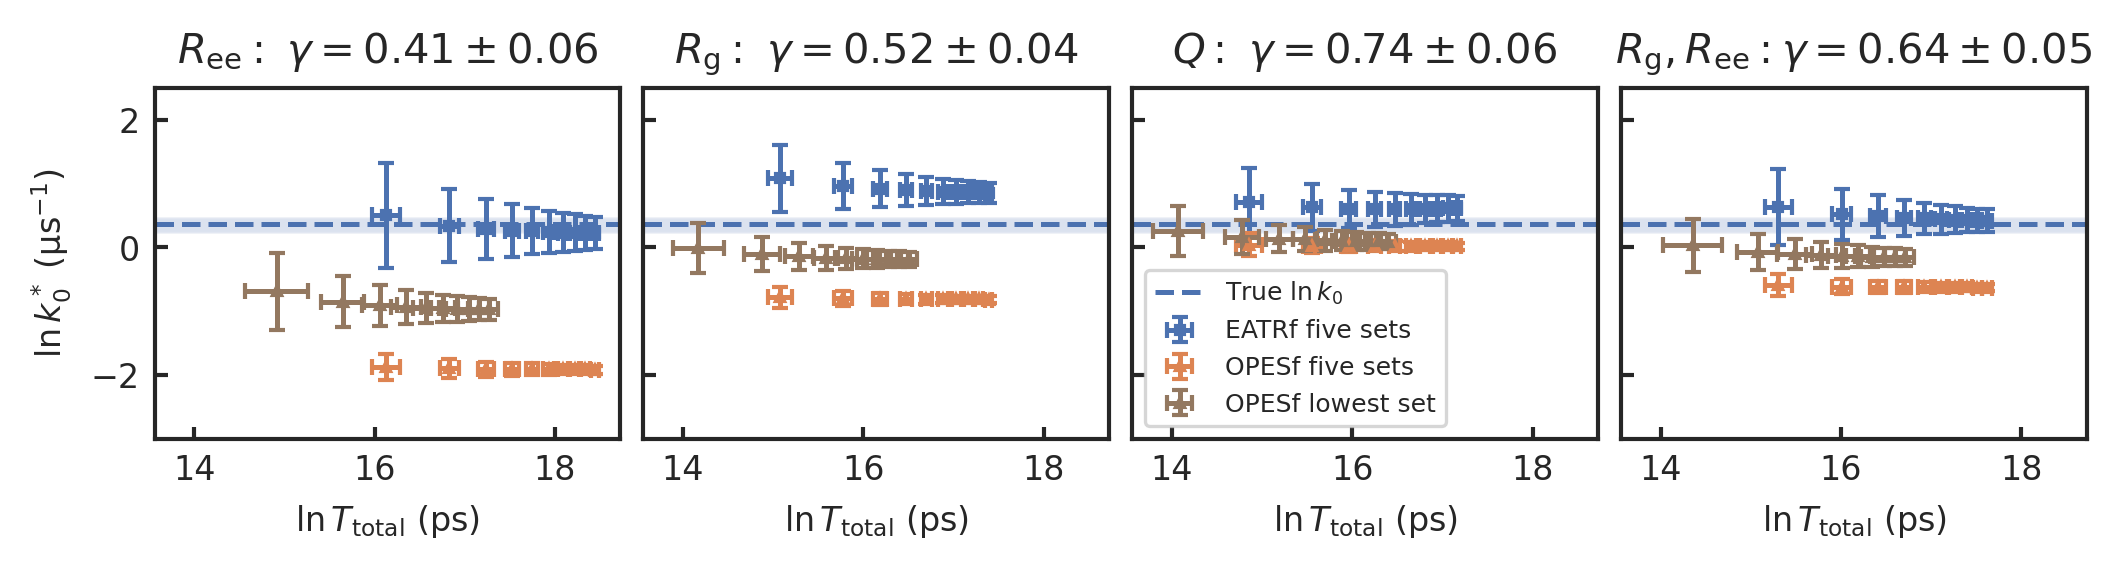

In [10]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(1,4,figsize=(7,1.8),dpi=300,sharey=True,sharex=True)
fig.subplots_adjust(wspace=0.05,bottom=0.2,left=0.07,right=0.99,top=0.85)

axs[0].axhline(np.log(true*1e6),color='C0',linestyle='--')
axs[0].errorbar(N_data_E[:,1],N_data_E[:,3]+np.log(1e6),xerr=N_data_E[:,2],yerr=N_data_E[:,4],linestyle='',marker='s',color=f'C0',capsize=2,markersize=2,label='EATRf five sets')
axs[0].errorbar(N_data_E[:,1],N_data_E[:,7]+np.log(1e6),xerr=N_data_E[:,2],yerr=N_data_E[:,8],linestyle='',marker='^',color=f'C1',capsize=2,markersize=2,label='OPESf five sets')
axs[0].errorbar(N_data_E_OPESf[:,1],N_data_E_OPESf[:,3]+np.log(1e6),xerr=N_data_E_OPESf[:,2],yerr=N_data_E_OPESf[:,4],linestyle='',marker='^',color=f'C5',capsize=2,markersize=2,label='OPESf lowest set')
axs[0].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
axs[0].set_title(r'$R_\mathrm{ee}:~\gamma=0.41\pm0.06$')
axs[0].set_ylim((-3,2.5))
axs[0].set_ylabel(r'$\ln k_0^*$ ($\mathrm{\mu s}^{-1}$)')

axs[1].axhline(np.log(true*1e6),color='C0',linestyle='--')
axs[1].errorbar(N_data_G[:,1],N_data_G[:,3]+np.log(1e6),xerr=N_data_G[:,2],yerr=N_data_G[:,4],linestyle='',marker='s',color=f'C0',capsize=2,markersize=2,label='EATRf five sets')
axs[1].errorbar(N_data_G[:,1],N_data_G[:,7]+np.log(1e6),xerr=N_data_G[:,2],yerr=N_data_G[:,8],linestyle='',marker='^',color=f'C1',capsize=2,markersize=2,label='OPESf five sets')
axs[1].errorbar(N_data_G_OPESf[:,1],N_data_G_OPESf[:,3]+np.log(1e6),xerr=N_data_G_OPESf[:,2],yerr=N_data_G_OPESf[:,4],linestyle='',marker='^',color=f'C5',capsize=2,markersize=2,label='OPESf lowest set')
axs[1].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
axs[1].set_title(r'$R_\mathrm{g}:~\gamma=0.52\pm0.04$')

axs[2].axhline(np.log(true*1e6),color='C0',linestyle='--',label=r'True $\ln k_0$')
axs[2].errorbar(N_data_Q[:,1],N_data_Q[:,3]+np.log(1e6),xerr=N_data_Q[:,2],yerr=N_data_Q[:,4],linestyle='',marker='s',color=f'C0',capsize=2,markersize=2,label='EATRf five sets')
axs[2].errorbar(N_data_Q[:,1],N_data_Q[:,7]+np.log(1e6),xerr=N_data_Q[:,2],yerr=N_data_Q[:,8],linestyle='',marker='^',color=f'C1',capsize=2,markersize=2,label='OPESf five sets')
axs[2].errorbar(N_data_Q_OPESf[:,1],N_data_Q_OPESf[:,3]+np.log(1e6),xerr=N_data_Q_OPESf[:,2],yerr=N_data_Q_OPESf[:,4],linestyle='',marker='^',color=f'C5',capsize=2,markersize=2,label='OPESf lowest set')
axs[2].legend(loc='lower left')
axs[2].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
axs[2].set_title(r'$Q:~\gamma=0.74\pm0.06$')

axs[3].axhline(np.log(true*1e6),color='C0',linestyle='--')
axs[3].errorbar(N_data_GE[:,1],N_data_GE[:,3]+np.log(1e6),xerr=N_data_GE[:,2],yerr=N_data_GE[:,4],linestyle='',marker='s',color=f'C0',capsize=2,markersize=2,label='EATRf five sets')
axs[3].errorbar(N_data_GE[:,1],N_data_GE[:,7]+np.log(1e6),xerr=N_data_GE[:,2],yerr=N_data_GE[:,8],linestyle='',marker='^',color=f'C1',capsize=2,markersize=2,label='OPESf five sets')
axs[3].errorbar(N_data_GE_OPESf[:,1],N_data_GE_OPESf[:,3]+np.log(1e6),xerr=N_data_GE_OPESf[:,2],yerr=N_data_GE_OPESf[:,4],linestyle='',marker='^',color=f'C5',capsize=2,markersize=2,label='OPESf lowest set')
axs[3].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
axs[3].set_title(r'$R_\mathrm{g},R_\mathrm{ee}:\gamma=0.64\pm0.05$')

for ax in axs.flatten():
    xlim = ax.get_xlim()
    ax.fill_between(xlim,k_low,k_high,alpha=0.2)
    ax.set_xlim(xlim)
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_Fig4.pdf",format='pdf')

In [11]:
print('running')

N_data_E2_low = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=2,Ns=[100])
N_data_E3_low = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=3,Ns=[100])
N_data_E4_low = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=4,Ns=[100])
N_data_E5_low = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=5,Ns=[100])

print('ran')

running
../../Data/protG/E_end_end_distance_opes
100
../../Data/protG/E_end_end_distance_opes
100
../../Data/protG/E_end_end_distance_opes
100
../../Data/protG/E_end_end_distance_opes
100
ran


In [12]:
print('running')

N_data_E2_high = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=-2,Ns=[100])
N_data_E3_high = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=-3,Ns=[100])
N_data_E4_high = get_Ndata('../../Data/protG/E_end_end_distance_opes','e',axis=0,biascol=4,a=-4,Ns=[100])

print('ran')

running
../../Data/protG/E_end_end_distance_opes
100
../../Data/protG/E_end_end_distance_opes
100
../../Data/protG/E_end_end_distance_opes
100
ran


running


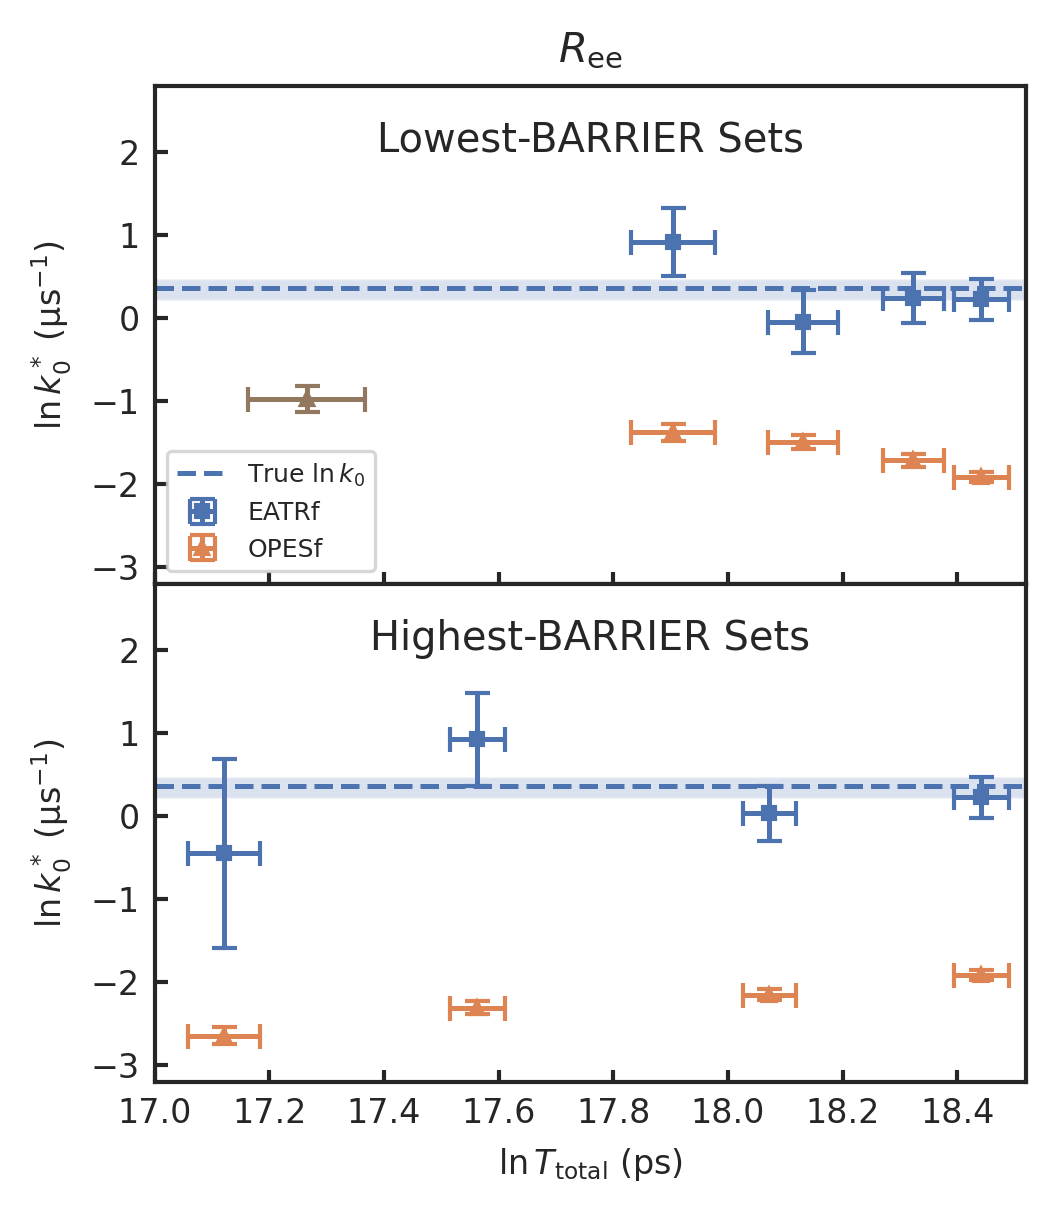

In [13]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(2,1,figsize=(3.5,4),dpi=300,sharey=True,sharex=True)
fig.subplots_adjust(wspace=0.2,hspace=0,bottom=0.1,left=0.15,right=0.98,top=0.93)

print('running')

axs[0].axhline(np.log(true*1e6),color='C0',linestyle='--',label='True $\ln k_0$')
axs[0].errorbar(N_data_E2_low[-1,1],N_data_E2_low[-1,3]+np.log(1e6),xerr=N_data_E2_low[-1,2],yerr=N_data_E2_low[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0',label='EATRf')
axs[0].errorbar(N_data_E2_low[-1,1],N_data_E2_low[-1,7]+np.log(1e6),xerr=N_data_E2_low[-1,2],yerr=N_data_E2_low[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1',label='OPESf')
axs[0].errorbar(N_data_E3_low[-1,1],N_data_E3_low[-1,3]+np.log(1e6),xerr=N_data_E3_low[-1,2],yerr=N_data_E3_low[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[0].errorbar(N_data_E3_low[-1,1],N_data_E3_low[-1,7]+np.log(1e6),xerr=N_data_E3_low[-1,2],yerr=N_data_E3_low[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[0].errorbar(N_data_E4_low[-1,1],N_data_E4_low[-1,3]+np.log(1e6),xerr=N_data_E4_low[-1,2],yerr=N_data_E4_low[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[0].errorbar(N_data_E4_low[-1,1],N_data_E4_low[-1,7]+np.log(1e6),xerr=N_data_E4_low[-1,2],yerr=N_data_E4_low[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[0].errorbar(N_data_E5_low[-1,1],N_data_E5_low[-1,3]+np.log(1e6),xerr=N_data_E5_low[-1,2],yerr=N_data_E5_low[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[0].errorbar(N_data_E5_low[-1,1],N_data_E5_low[-1,7]+np.log(1e6),xerr=N_data_E5_low[-1,2],yerr=N_data_E5_low[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[0].errorbar(N_data_E_OPESf[-1,1],N_data_E_OPESf[-1,3]+np.log(1e6),xerr=N_data_E_OPESf[-1,2],yerr=N_data_E_OPESf[-1,4],linestyle='',marker='^',capsize=3,markersize=3,color='C5')
#axs[0].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
axs[0].set_xlim((17,18.52))
#axs[0].set_xticks([])
axs[0].set_title(r'$R_\mathrm{ee}$')
axs[0].set_ylabel(r'$\ln k_0^*$ ($\mathrm{\mu s}^{-1}$)')
axs[0].legend(loc='lower left')
axs[0].text(np.mean(axs[0].get_xlim()),2,"Lowest-BARRIER Sets",horizontalalignment='center')

axs[1].axhline(np.log(true*1e6),color='C0',linestyle='--')
axs[1].errorbar(N_data_E2_high[-1,1],N_data_E2_high[-1,3]+np.log(1e6),xerr=N_data_E2_high[-1,2],yerr=N_data_E2_high[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0',label='EATRf')
axs[1].errorbar(N_data_E2_high[-1,1],N_data_E2_high[-1,7]+np.log(1e6),xerr=N_data_E2_high[-1,2],yerr=N_data_E2_high[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1',label='OPESf')
axs[1].errorbar(N_data_E3_high[-1,1],N_data_E3_high[-1,3]+np.log(1e6),xerr=N_data_E3_high[-1,2],yerr=N_data_E3_high[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[1].errorbar(N_data_E3_high[-1,1],N_data_E3_high[-1,7]+np.log(1e6),xerr=N_data_E3_high[-1,2],yerr=N_data_E3_high[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[1].errorbar(N_data_E4_high[-1,1],N_data_E4_high[-1,3]+np.log(1e6),xerr=N_data_E4_high[-1,2],yerr=N_data_E4_high[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[1].errorbar(N_data_E4_high[-1,1],N_data_E4_high[-1,7]+np.log(1e6),xerr=N_data_E4_high[-1,2],yerr=N_data_E4_high[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[1].errorbar(N_data_E5_low[-1,1],N_data_E5_low[-1,3]+np.log(1e6),xerr=N_data_E5_low[-1,2],yerr=N_data_E5_low[-1,4],linestyle='',marker='s',capsize=3,markersize=3,color='C0')
axs[1].errorbar(N_data_E5_low[-1,1],N_data_E5_low[-1,7]+np.log(1e6),xerr=N_data_E5_low[-1,2],yerr=N_data_E5_low[-1,8],linestyle='',marker='^',capsize=3,markersize=3,color='C1')
axs[1].set_ylabel(r'$\ln k_0^*$ ($\mathrm{\mu s}^{-1}$)')
axs[1].set_xlabel(r'$\ln T_\mathrm{total}$ (ps)')
#axs[1].set_title(r'$R_\mathrm{ee}$ Highest')
axs[1].set_ylim((-3.2,2.8))
axs[1].text(np.mean(axs[1].get_xlim()),2,"Highest-BARRIER Sets",horizontalalignment='center')
#axs[1].set_ylabel(r'$\ln k_{0,est}$ ($\mathrm{\mu s}^{-1}$)')

for ax in axs.flatten():
    xlim = ax.get_xlim()
    ax.fill_between(xlim,k_low,k_high,alpha=0.2)
    ax.set_xlim(xlim)
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_Fig5.pdf",format='pdf')